# Autoregressive Rollout Evaluation

Evaluates the trained conditional flow-matching model by rolling out predictions autoregressively:

$$\hat{x}_{t+1} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; x_t) \quad \rightarrow \quad \hat{x}_{t+2} = \text{ODE}(z_0 \sim \mathcal{N}(0,I),\; \hat{x}_{t+1}) \quad \rightarrow \quad \cdots$$

**Metrics:**
- **RMSE** — Root Mean Squared Error of the ensemble mean vs. ground truth
- **CRPS** — Continuous Ranked Probability Score (probabilistic skill of marginal distributions)
- **SSR** — Spread/Skill Ratio (calibration: should be ~1 for a well-calibrated ensemble)

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
from cond_sampler import CondSampler

# Import forecasting functions
from autoregressive_forecasting import (
    autoregressive_ensemble_rollout,
    compute_rmse,
    compute_crps,
    compute_ssr
)

## 2. Config

In [2]:
# ── paths ─────────────────────────────────────────────────────────────────
MODEL_PATH = Path('../models/1hour_1st_attempt.pth')

# ── data ──────────────────────────────────────────────────────────────────
DATA_STD   = 2660.0
TRAIN_FRAC = 0.8          # must match training split
# what's this

# ── model (must match training config exactly) ────────────────────────────
IMG_CHANNELS   = 2
IMG_RESOLUTION = 64
FILTERS        = 32
LABEL_DROPOUT  = 0.1

# ── evaluation ────────────────────────────────────────────────────────────
N_ENSEMBLE    = 10    # number of ensemble members per rollout
ROLLOUT_STEPS = 10    # how many autoregressive steps to evaluate
STEPS     = 100   # Euler steps inside each ODE solve
N_INIT    = 20    # number of different starting points to average metrics over

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Model path exists: {MODEL_PATH.exists()}')


Device: cuda
Model path exists: True


## 3. Load Data (val split only)

In [3]:
# load and split files by trajectory, not by time
hour = 1
DATA_DIR = Path('../data/') if hour ==1 else Path('../3hour_data/')
files = natsorted(DATA_DIR.glob(f'sqg_N64_{hour}hrly_*.npy'))
assert len(files) > 0, f"No files found in {DATA_DIR}"

cut        = int(len(files) * TRAIN_FRAC)
val_files  = files[cut:]
# should we use SQGPairDataset? it's for pair tho

# load all val trajectories
val_trajs = []
for f in val_files:
    arr = torch.tensor(np.load(f).astype(np.float32) / DATA_STD)  # (T, C, H, W)
    val_trajs.append(arr)

T_per_traj = val_trajs[0].shape[0]
print(f'Total trajectories: {len(files)},  train: {cut},  val: {len(val_files)}')
print(f'Timesteps per trajectory: {T_per_traj},  val data shape: {val_trajs[0].shape}')

# pick N_INIT (traj_idx, t) starting points from val trajectories
# ensure t + ROLLOUT_STEPS < T so we have enough ground truth
max_t      = T_per_traj - ROLLOUT_STEPS - 1
assert max_t > 0, 'Trajectory too short for requested rollout length'

rng          = np.random.default_rng(42)
traj_indices = rng.integers(0, len(val_trajs), size=N_INIT)
time_indices = rng.integers(0, max_t,          size=N_INIT)
init_points  = list(zip(traj_indices.tolist(), time_indices.tolist()))

print(f'\nSampled {N_INIT} init points: (traj_idx, t_start)')
for ti, t in init_points:
    print(f'  traj={ti}, t={t}')

Total trajectories: 100,  train: 80,  val: 20
Timesteps per trajectory: 101,  val data shape: torch.Size([101, 2, 64, 64])

Sampled 20 init points: (traj_idx, t_start)
  traj=1, t=45
  traj=15, t=33
  traj=13, t=16
  traj=8, t=83
  traj=8, t=70
  traj=17, t=57
  traj=1, t=36
  traj=13, t=74
  traj=4, t=49
  traj=1, t=39
  traj=10, t=40
  traj=19, t=20
  traj=14, t=8
  traj=15, t=49
  traj=14, t=79
  traj=15, t=5
  traj=10, t=77
  traj=2, t=74
  traj=16, t=24
  traj=9, t=56


## 4. Load Model


## 5. Sampling Function

These parts is done within cond_sampler.py

## 6. Metric Definitions

All metrics are computed **per lead time**, averaged over spatial pixels, channels, and init points.

- **RMSE**: $\sqrt{\mathbb{E}[(\bar{x}_{\text{pred}} - x_{\text{truth}})^2]}$ where $\bar{x}_{\text{pred}}$ is the ensemble mean
- **CRPS**: $\mathbb{E}_{m}[|x^m - x_{\text{truth}}|] - \frac{1}{2}\mathbb{E}_{m,m'}[|x^m - x^{m'}|]$ (energy form)
- **SSR**: $\frac{\text{ensemble spread}}{\text{RMSE}}$ — well-calibrated when $\approx 1$

## 7. Run Evaluation

In [4]:
all_rmse = []
all_crps = []
all_ssr  = []

eps = lambda t: 0.5 * (1 - t)  # Noise when sampling
invert_eps = lambda t: 0. * (1 - t)  # Noise when inverting
sampler = CondSampler(model_path=str(MODEL_PATH), device=device, steps=100, eps=eps, invert_eps=invert_eps)

for ti, t in tqdm(init_points, desc='Evaluating init points'):
    x0    = val_trajs[ti][t]                                    # (C, H, W)
    truth = val_trajs[ti][t + 1 : t + 1 + ROLLOUT_STEPS].numpy()  # (steps, C, H, W)

    # ensemble rollout
    preds = autoregressive_ensemble_rollout(x0, ROLLOUT_STEPS, N_ENSEMBLE, sampler=sampler, rho=0.9)   # (steps, n_ens, C, H, W)

    preds_mean = preds.mean(axis=1)                                # (steps, C, H, W)

    rmse = compute_rmse(preds_mean, truth)                         # (steps,)
    crps = compute_crps(preds, truth)                              # (steps,)
    ssr  = compute_ssr(preds, rmse)                                # (steps,)

    all_rmse.append(rmse)
    all_crps.append(crps)
    all_ssr.append(ssr)

# average over init points
mean_rmse = np.stack(all_rmse).mean(axis=0)   # (steps,)
mean_crps = np.stack(all_crps).mean(axis=0)
mean_ssr  = np.stack(all_ssr).mean(axis=0)

lead_times = np.arange(1, ROLLOUT_STEPS + 1)

print(f'\nResults averaged over {N_INIT} init points:')
print(f'{"Lead":>5}  {"RMSE":>8}  {"CRPS":>8}  {"SSR":>8}')
for t, r, c, s in zip(lead_times, mean_rmse, mean_crps, mean_ssr):
    print(f'{t:5d}  {r:8.4f}  {c:8.4f}  {s:8.4f}')

Evaluating init points: 100%|██████████| 20/20 [17:18<00:00, 51.92s/it]


Results averaged over 20 init points:
 Lead      RMSE      CRPS       SSR
    1    0.0191    0.0099    1.0006
    2    0.0309    0.0162    0.8440
    3    0.0400    0.0210    0.7826
    4    0.0478    0.0252    0.7450
    5    0.0548    0.0290    0.7185
    6    0.0617    0.0328    0.6969
    7    0.0687    0.0368    0.6762
    8    0.0760    0.0409    0.6552
    9    0.0838    0.0453    0.6348
   10    0.0918    0.0499    0.6148


## 8. Plot Metrics vs Lead Time

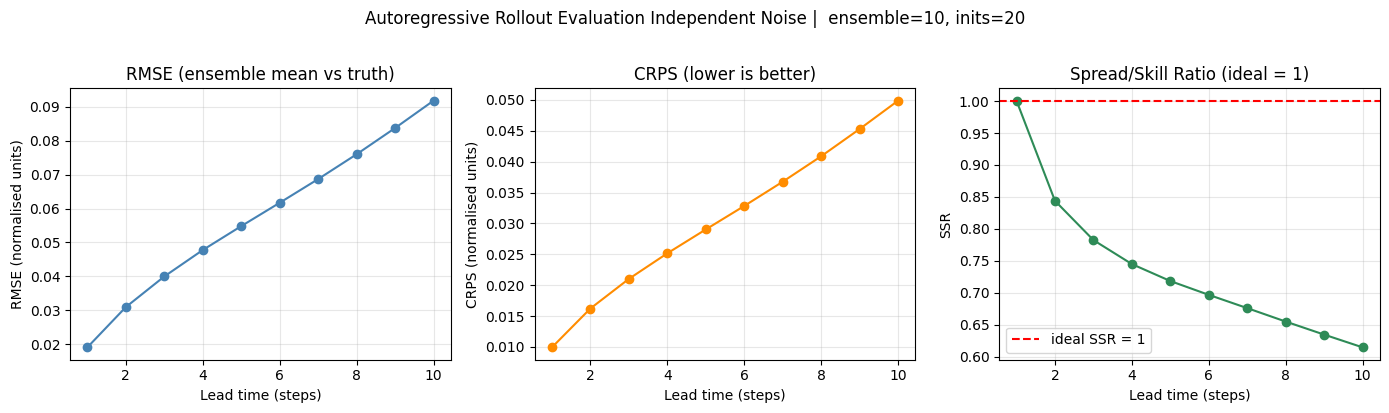

Plot saved to results/eval_metrics_independent_noise.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(lead_times, mean_rmse, marker='o', color='steelblue')
axes[0].set_title('RMSE (ensemble mean vs truth)')
axes[0].set_xlabel('Lead time (steps)')
axes[0].set_ylabel('RMSE (normalised units)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(lead_times, mean_crps, marker='o', color='darkorange')
axes[1].set_title('CRPS (lower is better)')
axes[1].set_xlabel('Lead time (steps)')
axes[1].set_ylabel('CRPS (normalised units)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(lead_times, mean_ssr, marker='o', color='seagreen')
axes[2].axhline(1.0, color='red', linestyle='--', label='ideal SSR = 1')
axes[2].set_title('Spread/Skill Ratio (ideal = 1)')
axes[2].set_xlabel('Lead time (steps)')
axes[2].set_ylabel('SSR')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Autoregressive Rollout Evaluation Independent Noise |  ensemble={N_ENSEMBLE}, inits={N_INIT}', y=1.02)
plt.tight_layout()
plt.show()
print('Plot saved to results/eval_metrics_independent_noise.png')

## 9. Visual Sanity Check — One Rollout Trajectory

Plots the ground truth vs ensemble mean for a single init point at selected lead times.